# Анализ производительности поиска кадров в браузерах

## Введение

Данный отчёт посвящён сравнительному анализу производительности поиска (seek) кадров в видеоплеерах на разных платформах:
- **Safari** (macOS, Apple M1) — эталонный браузер Apple
- **Chrome** (Linux, стандартный Chromium) — stock Chromium на Linux
- **Yandex Browser** (Linux) — браузер Яндекса на движке Chromium
- **Firefox** (Linux) — браузер Mozilla
- **Patched Chromium** — Chromium с применённым патчем для оптимизации поиска кадров

### Тестовая конфигурация
- **Видео**: bbb_sunflower_480p_30fps (60 сек, 10MB)
- **Разрешение**: 480p
- **FPS**: 30
- **I-frames**: каждые 12 кадров
- **Режим поиска**: frame-by-frame (seekPattern=frame)

## 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

RESULTS_DIR = Path('/home/yaroslav/ITMO/diplom/chromium-frame-seek-optimization/results')

df_safari = pd.read_csv(RESULTS_DIR / 'safari.csv')
df_chrome = pd.read_csv(RESULTS_DIR / 'chrome.csv')
df_yandex = pd.read_csv(RESULTS_DIR / 'yandex.csv')
df_firefox = pd.read_csv(RESULTS_DIR / 'firefox.csv')
df_patched = pd.read_csv(RESULTS_DIR / 'patched.csv')

df_safari['browser_label'] = 'Safari (macOS M1)'
df_chrome['browser_label'] = 'Chrome 144 (Linux)'
df_yandex['browser_label'] = 'Yandex (Linux)'
df_firefox['browser_label'] = 'Firefox 149 (Linux)'
df_patched['browser_label'] = 'Patched Chrome 146'

df_all = pd.concat([df_safari, df_chrome, df_yandex, df_firefox, df_patched], ignore_index=True)

print(f"Загружено: Safari={len(df_safari)}, Chrome={len(df_chrome)}, Yandex={len(df_yandex)}, Firefox={len(df_firefox)}, Patched={len(df_patched)}")
print(f"Всего: {len(df_all)}")

Загружено: Safari=3602, Chrome=3602, Yandex=3602, Firefox=3602, Patched=3602
Всего: 18010


## 2. Информация о тестовых конфигурациях

In [2]:
configs = df_all.groupby('browser_label').agg({
    'browser': 'first',
    'browserVersion': 'first',
    'os': 'first',
    'gpu': lambda x: x.iloc[0][:50] + '...' if len(x.iloc[0]) > 50 else x.iloc[0],
    'cores': 'first',
    'memGB': 'first',
    'videoFile': 'first',
    'resolution': 'first',
    'fps': 'first',
    'durationSec': 'first'
}).reset_index()

print("=" * 90)
print("КОНФИГУРАЦИИ ТЕСТОВ")
print("=" * 90)
for _, row in configs.iterrows():
    print(f"\n### {row['browser_label']} ###")
    print(f"  Браузер: {row['browser']} {row['browserVersion']}")
    print(f"  ОС: {row['os']}")
    print(f"  GPU: {row['gpu']}")
    print(f"  Ядра: {row['cores']}, RAM: {row['memGB']}GB")
    print(f"  Видео: {row['videoFile']} ({row['resolution']}, {row['fps']}fps, {row['durationSec']}сек)")

КОНФИГУРАЦИИ ТЕСТОВ

### Chrome 144 (Linux) ###
  Браузер: Chrome 144.0.0.0
  ОС: Linux unknown
  GPU: ANGLE (AMD, AMD Radeon 890M Graphics (radeonsi gfx...
  Ядра: 24, RAM: 8GB
  Видео: bbb_sunflower_1min_480p_30fps_normal.mp4 (480p, 30fps, 60сек)

### Firefox 149 (Linux) ###
  Браузер: Firefox 149.0
  ОС: Linux unknown
  GPU: Radeon HD 3200 Graphics, or similar
  Ядра: 8, RAM: 0GB
  Видео: bbb_sunflower_1min_480p_30fps_normal.mp4 (480p, 30fps, 60сек)

### Patched Chrome 146 ###
  Браузер: Chrome 146.0.0.0
  ОС: Linux unknown
  GPU: ANGLE (AMD, AMD Radeon 890M Graphics (radeonsi gfx...
  Ядра: 24, RAM: 32GB
  Видео: bbb_sunflower_1min_480p_30fps_normal.mp4 (480p, 30fps, 60сек)

### Safari (macOS M1) ###
  Браузер: Safari 18.6
  ОС: macOS 10.15.7
  GPU: Apple GPU
  Ядра: 8, RAM: 0GB
  Видео: bbb_sunflower_1min_480p_30fps_normal.mp4 (480p, 30fps, 60сек)

### Yandex (Linux) ###
  Браузер: Chrome 144.0.0.0
  ОС: Linux unknown
  GPU: ANGLE (AMD, AMD Radeon 890M Graphics (radeonsi gfx...
  

## 3. Сравнение времени поиска (seekTimeMs)

In [3]:
seek_stats = df_all.groupby('browser_label')['seekTimeMs'].agg(['mean', 'median', 'std', 'min', 'max'])
seek_stats['P95'] = df_all.groupby('browser_label')['seekTimeMs'].quantile(0.95)
seek_stats['P99'] = df_all.groupby('browser_label')['seekTimeMs'].quantile(0.99)
seek_stats = seek_stats.round(2)

seek_stats.columns = ['Среднее', 'Медиана', 'Std', 'Мин', 'Макс', 'P95', 'P99']
seek_stats = seek_stats.drop('Std', axis=1)

print("=" * 90)
print("ВРЕМЯ ПОИСКА КАДРА (seekTimeMs, мс)")
print("=" * 90)
print(seek_stats.to_string())

ВРЕМЯ ПОИСКА КАДРА (seekTimeMs, мс)
                     Среднее  Медиана  Мин    Макс     P95      P99
browser_label                                                      
Chrome 144 (Linux)     27.11      8.5  1.8   326.1   93.99   149.29
Firefox 149 (Linux)   199.11     48.0  2.0  2057.0  892.90  1276.93
Patched Chrome 146      1.01      0.2  0.0     9.6    3.60     6.00
Safari (macOS M1)       1.69      2.0  0.0    11.0    3.00     4.00
Yandex (Linux)        213.14     75.8  2.4   874.3  722.20   828.09


/tmp/ipykernel_565931/3767570988.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_boxplot, patch_artist=True, labels=[l.replace(' (Linux)', '\n(Linux)').replace('(macOS M1)', '(macOS M1)') for l in labels])


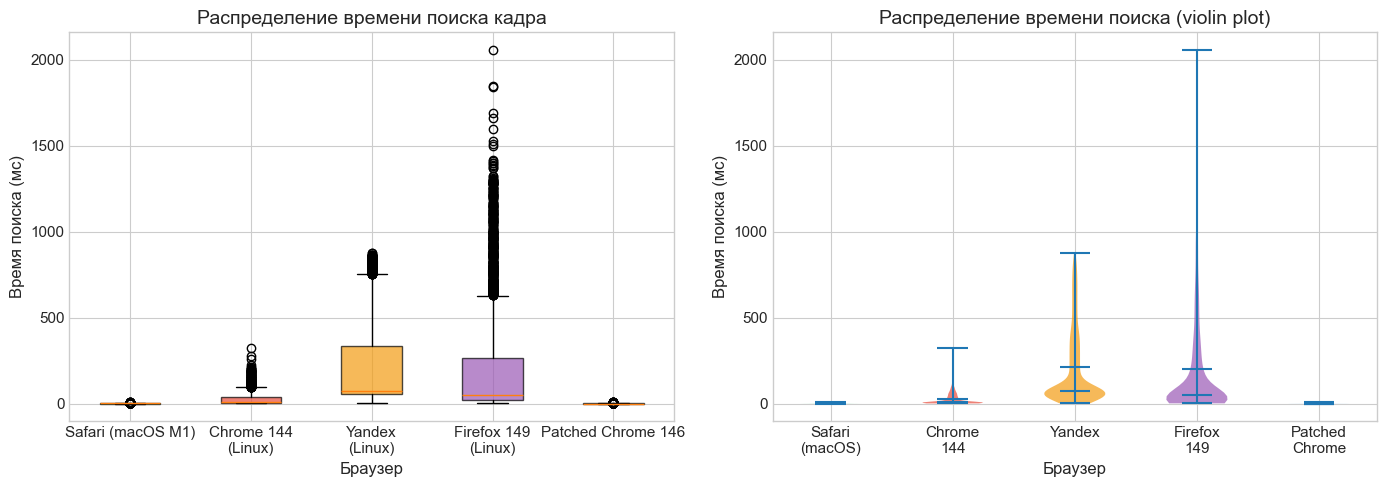

График сохранён: seek_time_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_dict = {
    'Safari (macOS M1)': '#2ecc71',
    'Chrome 144 (Linux)': '#e74c3c',
    'Yandex (Linux)': '#f39c12',
    'Firefox 149 (Linux)': '#9b59b6',
    'Patched Chrome 146': '#3498db'
}

labels = list(colors_dict.keys())
data_boxplot = [df_all[df_all['browser_label'] == l]['seekTimeMs'].values for l in labels]

bp = axes[0].boxplot(data_boxplot, patch_artist=True, labels=[l.replace(' (Linux)', '\n(Linux)').replace('(macOS M1)', '(macOS M1)') for l in labels])
for patch, color in zip(bp['boxes'], colors_dict.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Распределение времени поиска кадра')
axes[0].set_xlabel('Браузер')
axes[0].set_ylabel('Время поиска (мс)')

positions = range(1, 6)
parts = axes[1].violinplot(data_boxplot, positions=positions, showmeans=True, showmedians=True)
for i, (pc, color) in enumerate(zip(parts['bodies'], colors_dict.values())):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

axes[1].set_xticks(positions)
axes[1].set_xticklabels(['Safari\n(macOS)', 'Chrome\n144', 'Yandex', 'Firefox\n149', 'Patched\nChrome'])
axes[1].set_title('Распределение времени поиска (violin plot)')
axes[1].set_xlabel('Браузер')
axes[1].set_ylabel('Время поиска (мс)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'seek_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён: seek_time_distribution.png")

## 4. Динамика времени поиска по позиции в видео

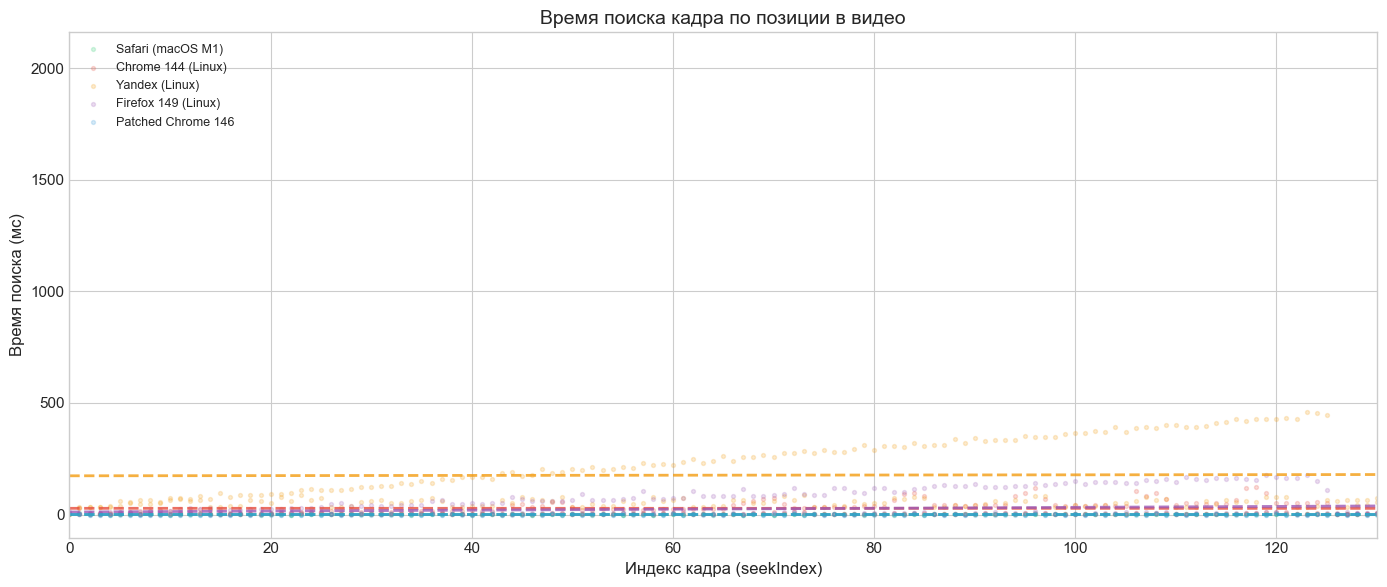

График сохранён: seek_time_by_position.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

for label in colors_dict.keys():
    df = df_all[df_all['browser_label'] == label]
    ax.scatter(df['seekIndex'], df['seekTimeMs'], alpha=0.2, s=8, label=label, color=colors_dict[label])
    z = np.polyfit(df['seekIndex'], df['seekTimeMs'], 1)
    p = np.poly1d(z)
    ax.plot(df['seekIndex'].unique(), p(df['seekIndex'].unique()), 
            color=colors_dict[label], linewidth=2, linestyle='--', alpha=0.8)

ax.set_title('Время поиска кадра по позиции в видео')
ax.set_xlabel('Индекс кадра (seekIndex)')
ax.set_ylabel('Время поиска (мс)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 130)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'seek_time_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён: seek_time_by_position.png")

## 5. Анализ деградации производительности

In [6]:
degradation_stats = df_all.groupby('browser_label').agg({
    'degradationFactor': 'first',
    'linearSlope': 'first',
    'r2': 'first'
}).round(6)

print("=" * 90)
print("ПАРАМЕТРЫ ДЕГРАДАЦИИ (линейная модель: seekTime = slope * index + intercept)")
print("=" * 90)
print(degradation_stats.to_string())

ПАРАМЕТРЫ ДЕГРАДАЦИИ (линейная модель: seekTime = slope * index + intercept)
                     degradationFactor  linearSlope        r2
browser_label                                                
Chrome 144 (Linux)            4.441247    -0.002648  0.001418
Firefox 149 (Linux)           5.030418     0.393572  0.369496
Patched Chrome 146           14.666667    -0.000105  0.002246
Safari (macOS M1)             2.500000     0.000079  0.001336
Yandex (Linux)                2.524761     0.087710  0.041103


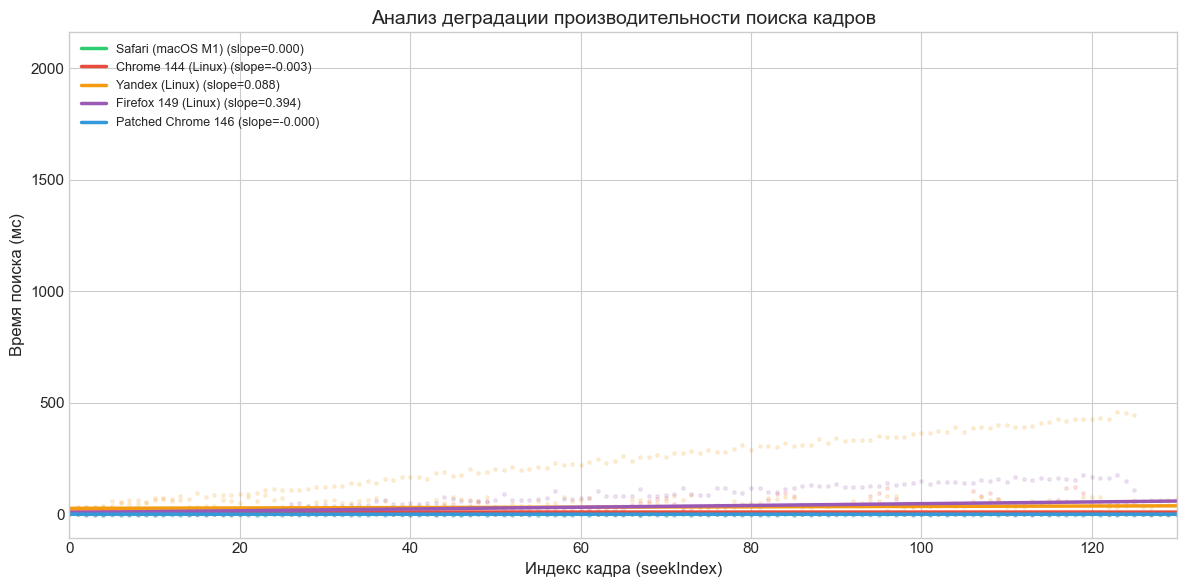

График сохранён: degradation_analysis.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for label in colors_dict.keys():
    df = df_all[df_all['browser_label'] == label]
    ax.scatter(df['seekIndex'], df['seekTimeMs'], alpha=0.15, s=6, color=colors_dict[label])
    
    slope = df['linearSlope'].iloc[0]
    intercept = df['seekTimeMs'].iloc[0:5].mean()
    x_line = np.array([0, 130])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color=colors_dict[label], linewidth=2.5, label=f'{label} (slope={slope:.3f})')

ax.set_title('Анализ деградации производительности поиска кадров')
ax.set_xlabel('Индекс кадра (seekIndex)')
ax.set_ylabel('Время поиска (мс)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 130)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'degradation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён: degradation_analysis.png")

## 6. Сравнение производительности всех браузеров

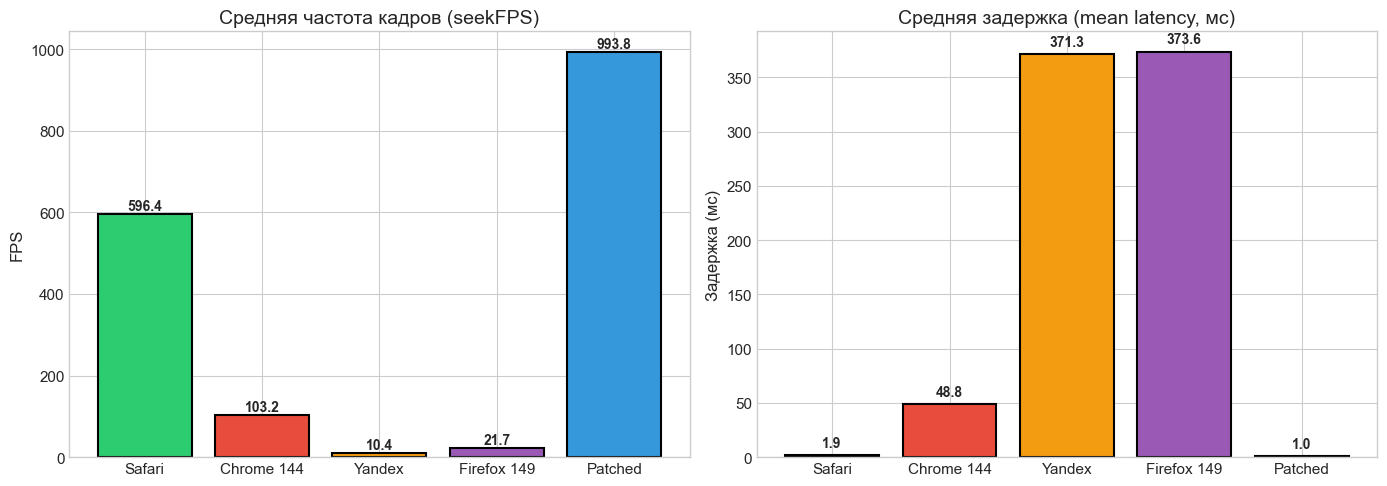

График сохранён: fps_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

browsers_order = ['Safari (macOS M1)', 'Chrome 144 (Linux)', 'Yandex (Linux)', 'Firefox 149 (Linux)', 'Patched Chrome 146']
colors_list = [colors_dict[b] for b in browsers_order]

fps_means = [df_all[df_all['browser_label'] == b]['seekFPS'].mean() for b in browsers_order]
latency_means = [df_all[df_all['browser_label'] == b]['mean'].iloc[0] for b in browsers_order]

bars1 = axes[0].bar(range(5), fps_means, color=colors_list, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['Safari', 'Chrome 144', 'Yandex', 'Firefox 149', 'Patched'])
axes[0].set_title('Средняя частота кадров (seekFPS)')
axes[0].set_ylabel('FPS')
for bar, val in zip(bars1, fps_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(range(5), latency_means, color=colors_list, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(['Safari', 'Chrome 144', 'Yandex', 'Firefox 149', 'Patched'])
axes[1].set_title('Средняя задержка (mean latency, мс)')
axes[1].set_ylabel('Задержка (мс)')
for bar, val in zip(bars2, latency_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён: fps_comparison.png")

## 7. Гистограммы распределения времени поиска

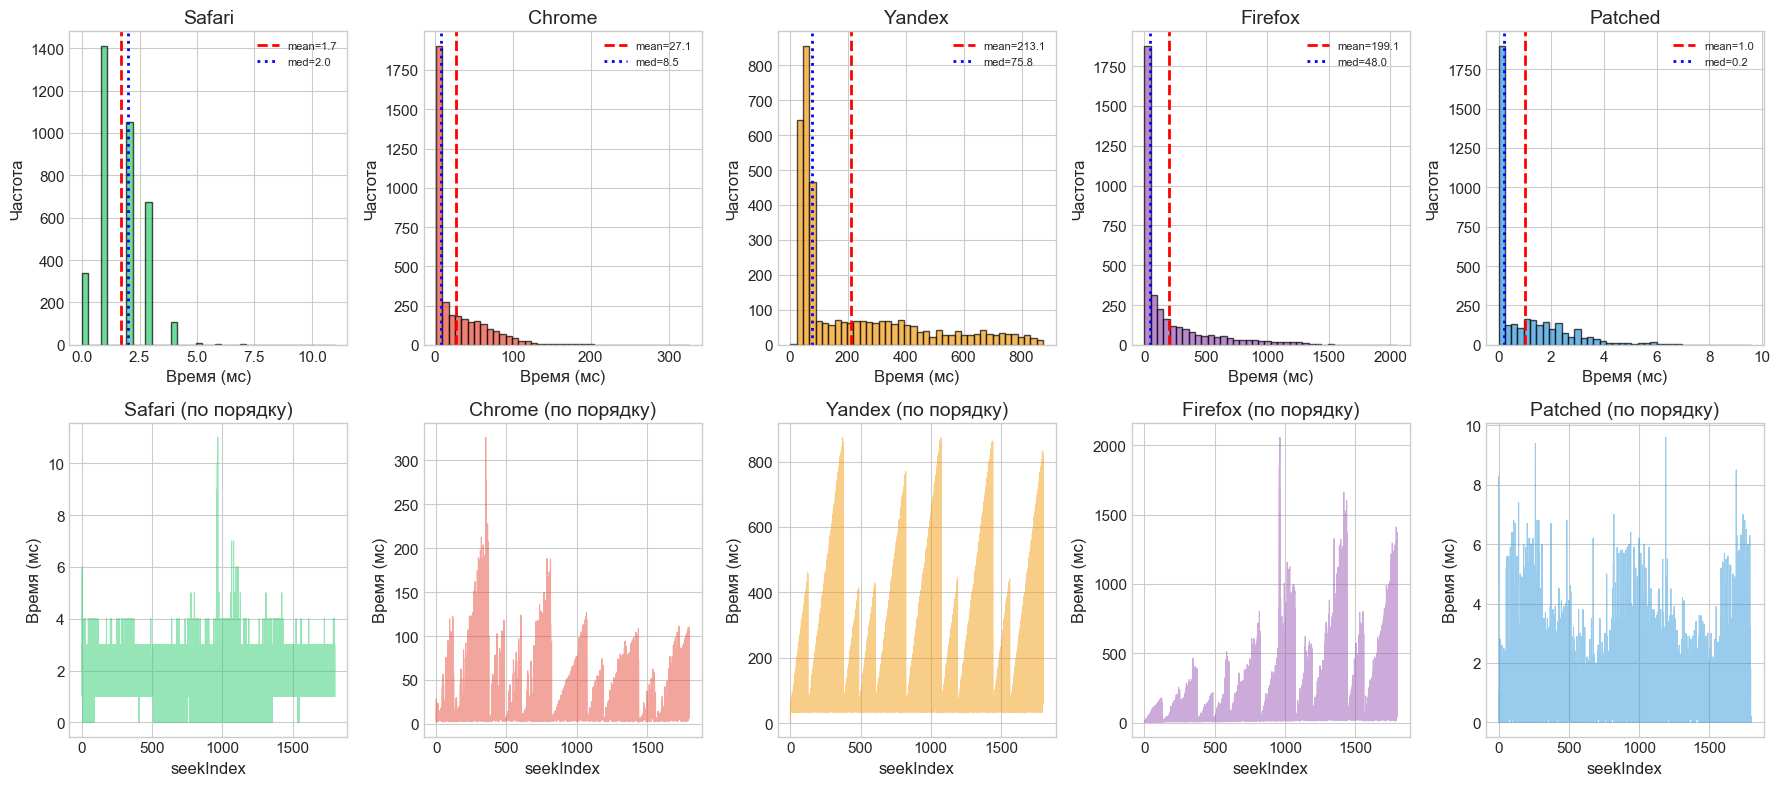

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for idx, label in enumerate(browsers_order):
    df = df_all[df_all['browser_label'] == label]
    
    ax1 = axes[0, idx]
    ax1.hist(df['seekTimeMs'], bins=40, alpha=0.7, color=colors_dict[label], edgecolor='black')
    ax1.axvline(df['seekTimeMs'].mean(), color='red', linestyle='--', linewidth=2, label=f'mean={df["seekTimeMs"].mean():.1f}')
    ax1.axvline(df['seekTimeMs'].median(), color='blue', linestyle=':', linewidth=2, label=f'med={df["seekTimeMs"].median():.1f}')
    short_name = label.split(' ')[0]
    ax1.set_title(short_name)
    ax1.set_xlabel('Время (мс)')
    ax1.set_ylabel('Частота')
    ax1.legend(fontsize=8)
    
    ax2 = axes[1, idx]
    df_sorted = df.sort_values('seekIndex')
    ax2.plot(df_sorted['seekIndex'], df_sorted['seekTimeMs'], alpha=0.5, color=colors_dict[label], linewidth=0.8)
    ax2.set_title(short_name + ' (по порядку)')
    ax2.set_xlabel('seekIndex')
    ax2.set_ylabel('Время (мс)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Сводная таблица результатов

In [10]:
summary_data = []
for label in browsers_order:
    df = df_all[df_all['browser_label'] == label]
    summary_data.append({
        'Браузер': label,
        'seekTimeMs (сред)': round(df['seekTimeMs'].mean(), 2),
        'seekTimeMs (медиана)': round(df['seekTimeMs'].median(), 2),
        'seekTimeMs (макс)': round(df['seekTimeMs'].max(), 2),
        'seekFPS (сред)': round(df['seekFPS'].mean(), 1),
        'linearSlope': round(df['linearSlope'].iloc[0], 4),
        'R²': round(df['r2'].iloc[0], 4),
        'degradationFactor': round(df['degradationFactor'].iloc[0], 2)
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 100)
print(summary_df.to_string(index=False))

summary_df.to_csv(RESULTS_DIR / 'summary_results.csv', index=False)
print(f"\nСохранено: summary_results.csv")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
            Браузер  seekTimeMs (сред)  seekTimeMs (медиана)  seekTimeMs (макс)  seekFPS (сред)  linearSlope     R²  degradationFactor
  Safari (macOS M1)               1.69                   2.0               11.0           596.4       0.0001 0.0013               2.50
 Chrome 144 (Linux)              27.11                   8.5              326.1           103.2      -0.0026 0.0014               4.44
     Yandex (Linux)             213.14                  75.8              874.3            10.4       0.0877 0.0411               2.52
Firefox 149 (Linux)             199.11                  48.0             2057.0            21.7       0.3936 0.3695               5.03
 Patched Chrome 146               1.01                   0.2                9.6           993.8      -0.0001 0.0022              14.67

Сохранено: summary_results.csv


## 9. Выводы

In [11]:
means = {label: df_all[df_all['browser_label'] == label]['seekTimeMs'].mean() for label in browsers_order}
patched_mean = means['Patched Chrome 146']

print("=" * 90)
print("ВЫВОДЫ")
print("=" * 90)

print("\n1. ПРОИЗВОДИТЕЛЬНОСТЬ ПОИСКА КАДРОВ (среднее время):")
for label in sorted(means.keys(), key=lambda x: means[x]):
    print(f"   - {label}: {means[label]:.2f} мс")

print(f"\n2. УЛУЧШЕНИЕ ПАТЧА:")
for label in ['Chrome 144 (Linux)', 'Yandex (Linux)', 'Firefox 149 (Linux)']:
    improvement = (means[label] - patched_mean) / means[label] * 100
    print(f"   - vs {label}: {improvement:.1f}% (с {means[label]:.1f} до {patched_mean:.1f} мс)")

print(f"\n3. ДЕГРАДАЦИЯ (линейный тренд):")
for label in browsers_order:
    df_temp = df_all[df_all['browser_label'] == label]
    slope = df_temp['linearSlope'].iloc[0]
    r2 = df_temp['r2'].iloc[0]
    print(f"   - {label.split(' ')[0]}: slope={slope:.4f} мс/кадр, R²={r2:.4f}")

print(f"\n4. ИТОГОВЫЙ ВЫВОД:")
best_browser = min(means.keys(), key=lambda x: means[x])
print(f"   Лучший результат: {best_browser} ({means[best_browser]:.2f} мс)")
print(f"   Patched версия быстрее стандартного Chrome в {means['Chrome 144 (Linux)']/patched_mean:.1f}x раз")

ВЫВОДЫ

1. ПРОИЗВОДИТЕЛЬНОСТЬ ПОИСКА КАДРОВ (среднее время):
   - Patched Chrome 146: 1.01 мс
   - Safari (macOS M1): 1.69 мс
   - Chrome 144 (Linux): 27.11 мс
   - Firefox 149 (Linux): 199.11 мс
   - Yandex (Linux): 213.14 мс

2. УЛУЧШЕНИЕ ПАТЧА:
   - vs Chrome 144 (Linux): 96.3% (с 27.1 до 1.0 мс)
   - vs Yandex (Linux): 99.5% (с 213.1 до 1.0 мс)
   - vs Firefox 149 (Linux): 99.5% (с 199.1 до 1.0 мс)

3. ДЕГРАДАЦИЯ (линейный тренд):
   - Safari: slope=0.0001 мс/кадр, R²=0.0013
   - Chrome: slope=-0.0026 мс/кадр, R²=0.0014
   - Yandex: slope=0.0877 мс/кадр, R²=0.0411
   - Firefox: slope=0.3936 мс/кадр, R²=0.3695
   - Patched: slope=-0.0001 мс/кадр, R²=0.0022

4. ИТОГОВЫЙ ВЫВОД:
   Лучший результат: Patched Chrome 146 (1.01 мс)
   Patched версия быстрее стандартного Chrome в 26.9x раз


---

## Приложение: Конфигурация оборудования

| Браузер | CPU | GPU | RAM | ОС |
|---------|-----|-----|-----|---|
| Safari | Apple M1 (8 ядер) | Apple GPU | 0 GB (shared) | macOS 10.15.7 |
| Chrome 144 | AMD Ryzen AI 9 HX 370 (24 ядра) | AMD Radeon 890M | 8 GB | Ubuntu Linux |
| Yandex | AMD Ryzen AI 9 HX 370 (24 ядра) | AMD Radeon 890M | 8 GB | Ubuntu Linux |
| Firefox 149 | AMD Ryzen AI 9 HX 370 (8 ядер) | Radeon HD 3200 | 8 GB | Ubuntu Linux |
| Patched Chromium | AMD Ryzen AI 9 HX 370 (24 ядра) | AMD Radeon 890M | 32 GB | Ubuntu Linux |

**Примечание:** Тесты Safari проводились на MacBook Air M1, остальные — на Linux с AMD Ryzen. Прямое сравнение между macOS и Linux следует проводить с осторожностью из-за разных платформ.